In [2]:
# accesso a google drive
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


Import dataset Routes

In [3]:
# import del database routes
import pandas as pd
df_routes_ori = pd.read_csv("drive/MyDrive/Progetto Data Analytics/routes.csv")
df_routes_ori

,index,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2
...,...,...,...,...,...,...,...,...,...,...
67658,67658,ZL,4178,WYA,6334,ADL,3341,NaN,0,SF3
67659,67659,ZM,19016,DME,4029,FRU,2912,NaN,0,734
67660,67660,ZM,19016,FRU,2912,DME,4029,NaN,0,734
67661,67661,ZM,19016,FRU,2912,OSS,2913,NaN,0,734


In [4]:
# Rimuoviamo le righe in cui il valore della colonna 'Stops' è diverso da 0 (ci occupiamo di voli diretti)
df_routes_ori = df_routes_ori.loc[df_routes_ori['Stops'] == 0]
df_routes_ori.head()

,index,Airline,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Codeshare,Stops,Equipment
0,0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


In [5]:
df_routes = df_routes_ori.loc[:, ['Source airport', 'Source airport ID', 'Destination airport', 'Destination airport ID']]
df_routes.head()

,Source airport,Source airport ID,Destination airport,Destination airport ID
0,AER,2965,KZN,2990
1,ASF,2966,KZN,2990
2,ASF,2966,MRV,2962
3,CEK,2968,KZN,2990
4,CEK,2968,OVB,4078


Import dataset Airports

In [6]:
#import del db airports, per capire dove sono situati i diversi aeroporti

df_airports = pd.read_csv("drive/MyDrive/Progetto Data Analytics/airports.csv")
df_airports

,index,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone,Type,Source
0,0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
1,1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
2,2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
3,3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
4,4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7693,7693,14106,Rogachyovo Air Base,Belaya,Russia,\N,ULDA,71.616699,52.478298,272,\N,\N,\N,airport,OurAirports
7694,7694,14107,Ulan-Ude East Airport,Ulan Ude,Russia,\N,XIUW,51.849998,107.737999,1670,\N,\N,\N,airport,OurAirports
7695,7695,14108,Krechevitsy Air Base,Novgorod,Russia,\N,ULLK,58.625000,31.385000,85,\N,\N,\N,airport,OurAirports
7696,7696,14109,Desierto de Atacama Airport,Copiapo,Chile,CPO,SCAT,-27.261200,-70.779198,670,\N,\N,\N,airport,OurAirports


In [7]:
# Selezioniamo solo i record con paesi desiderati
countries_to_keep = ['Italy']
df_airports = df_airports[df_airports['Country'].isin(countries_to_keep)]
df_airports

,index,Airport ID,Name,City,Country,IATA,ICAO,Latitude,Longitude,Altitude,Timezone,DST,Tz database time zone,Type,Source
1459,1459,1499,Amendola Air Base,Amendola,Italy,\N,LIBA,41.541401,15.718100,183,1,E,Europe/Rome,airport,OurAirports
1460,1460,1500,Crotone Airport,Crotone,Italy,CRV,LIBC,38.997200,17.080200,522,1,E,Europe/Rome,airport,OurAirports
1461,1461,1501,Bari Karol Wojtyła Airport,Bari,Italy,BRI,LIBD,41.138901,16.760599,177,1,E,Europe/Rome,airport,OurAirports
1462,1462,1502,"Foggia ""Gino Lisa"" Airport",Foggia,Italy,FOG,LIBF,41.432899,15.535000,265,1,E,Europe/Rome,airport,OurAirports
1463,1463,1503,"Taranto-Grottaglie ""Marcello Arlotta"" Airport",Grottaglie,Italy,TAR,LIBG,40.517502,17.403200,215,1,E,Europe/Rome,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7123,7123,11886,Casale Monferrato Airport,Casale Monferrato,Italy,\N,LILM,45.111198,8.456030,377,\N,\N,\N,airport,OurAirports
7124,7124,11887,Varese-Venegono Airport,Varese,Italy,\N,LILN,45.742199,8.888233,1050,\N,\N,\N,airport,OurAirports
7125,7125,11888,Novi Ligure Airport,Novi Ligure,Italy,\N,LIMR,44.779999,8.786390,607,\N,\N,\N,airport,OurAirports
7126,7126,11889,Sarzana-Luni Air Base,Sarzana (SP),Italy,QLP,LIQW,44.088001,9.987950,45,\N,\N,\N,airport,OurAirports


In [8]:
# Selezioniamo solo le colonne desiderate
df_airports = df_airports.loc[:, ['Airport ID', 'Name', 'City', 'Country']]
df_airports.head()

,Airport ID,Name,City,Country
1459,1499,Amendola Air Base,Amendola,Italy
1460,1500,Crotone Airport,Crotone,Italy
1461,1501,Bari Karol Wojtyła Airport,Bari,Italy
1462,1502,"Foggia ""Gino Lisa"" Airport",Foggia,Italy
1463,1503,"Taranto-Grottaglie ""Marcello Arlotta"" Airport",Grottaglie,Italy


In [9]:
# Eliminiamo i record con 'Source Airport ID' uguale a '\N'
df_routes = df_routes[df_routes['Source airport ID'] != '\\N']

# Eliminiamo i record con 'Destination Airport ID' uguale a '\N'
df_routes = df_routes[df_routes['Destination airport ID'] != '\\N']

# Trasformiamo la colonna 'Source Airport ID' in tipo int64
df_routes['Source airport ID'] = df_routes['Source airport ID'].astype('int64')

# Trasformiamo la colonna 'Destination Airport ID' in tipo int64
df_routes['Destination airport ID'] = df_routes['Destination airport ID'].astype('int64')

#df_routes

Creazione di un unico dataset

In [10]:
# Eseguiamo l'inner join sugli aeroporti di partenza
df_merged = pd.merge(df_routes, df_airports, left_on='Source airport ID', right_on='Airport ID', how='inner')
df_merged

,Source airport,Source airport ID,Destination airport,Destination airport ID,Airport ID,Name,City,Country
0,BDS,1506,ZRH,1678,1506,Brindisi – Salento Airport,Brindisi,Italy
1,BDS,1506,STR,350,1506,Brindisi – Salento Airport,Brindisi,Italy
2,BDS,1506,MUC,346,1506,Brindisi – Salento Airport,Brindisi,Italy
3,BDS,1506,ZRH,1678,1506,Brindisi – Salento Airport,Brindisi,Italy
4,BDS,1506,FCO,1555,1506,Brindisi – Salento Airport,Brindisi,Italy
...,...,...,...,...,...,...,...,...
1770,PMF,1531,STN,548,1531,Parma Airport,Parma,Italy
1771,PMF,1531,TPS,1515,1531,Parma Airport,Parma,Italy
1772,RMI,1546,KRR,2960,1546,Federico Fellini International Airport,Rimini,Italy
1773,RMI,1546,DME,4029,1546,Federico Fellini International Airport,Rimini,Italy


In [11]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged = df_merged.drop(columns=['Airport ID'])

# Rinominiamo le colonne, in vista della seconda merge
df_merged = df_merged.rename(columns={
    'Name': 'Source airport name',
    'City': 'Source airport city',
    'Country': 'Source airport country'
})

df_merged.head()

,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country
0,BDS,1506,ZRH,1678,Brindisi – Salento Airport,Brindisi,Italy
1,BDS,1506,STR,350,Brindisi – Salento Airport,Brindisi,Italy
2,BDS,1506,MUC,346,Brindisi – Salento Airport,Brindisi,Italy
3,BDS,1506,ZRH,1678,Brindisi – Salento Airport,Brindisi,Italy
4,BDS,1506,FCO,1555,Brindisi – Salento Airport,Brindisi,Italy


In [12]:
# Eseguiamo l'inner join sugli aeroporti di destinazione
df_merged = pd.merge(df_merged, df_airports, left_on='Destination airport ID', right_on='Airport ID', how='inner')
df_merged

,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Airport ID,Name,City,Country
0,BDS,1506,FCO,1555,Brindisi – Salento Airport,Brindisi,Italy,1555,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
1,NAP,1561,FCO,1555,Naples International Airport,Naples,Italy,1555,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
2,OLB,1520,FCO,1555,Olbia Costa Smeralda Airport,Olbia,Italy,1555,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
3,BLQ,1538,FCO,1555,Bologna Guglielmo Marconi Airport,Bologna,Italy,1555,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
4,AOI,4309,FCO,1555,Ancona Falconara Airport,Ancona,Italy,1555,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
...,...,...,...,...,...,...,...,...,...,...,...
420,PSA,1562,CIY,9327,Pisa International Airport,Pisa,Italy,9327,Comiso Airport,Comiso,Italy
421,CIA,1553,CIY,9327,Ciampino–G. B. Pastine International Airport,Rome,Italy,9327,Comiso Airport,Comiso,Italy
422,PMO,1512,PNL,1511,Falcone–Borsellino Airport,Palermo,Italy,1511,Pantelleria Airport,Pantelleria,Italy
423,VCE,1551,PNL,1511,Venice Marco Polo Airport,Venice,Italy,1511,Pantelleria Airport,Pantelleria,Italy


In [13]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged = df_merged.drop(columns=['Airport ID'])

# Rinominiamo le colonne
df_merged = df_merged.rename(columns={
    'Name': 'Destination airport name',
    'City': 'Destination airport city',
    'Country': 'Destination airport country'
})

df_merged

,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Destination airport name,Destination airport city,Destination airport country
0,BDS,1506,FCO,1555,Brindisi – Salento Airport,Brindisi,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
1,NAP,1561,FCO,1555,Naples International Airport,Naples,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
2,OLB,1520,FCO,1555,Olbia Costa Smeralda Airport,Olbia,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
3,BLQ,1538,FCO,1555,Bologna Guglielmo Marconi Airport,Bologna,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
4,AOI,4309,FCO,1555,Ancona Falconara Airport,Ancona,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy
...,...,...,...,...,...,...,...,...,...,...
420,PSA,1562,CIY,9327,Pisa International Airport,Pisa,Italy,Comiso Airport,Comiso,Italy
421,CIA,1553,CIY,9327,Ciampino–G. B. Pastine International Airport,Rome,Italy,Comiso Airport,Comiso,Italy
422,PMO,1512,PNL,1511,Falcone–Borsellino Airport,Palermo,Italy,Pantelleria Airport,Pantelleria,Italy
423,VCE,1551,PNL,1511,Venice Marco Polo Airport,Venice,Italy,Pantelleria Airport,Pantelleria,Italy


In [14]:
# Contiamo il numero di duplicati per ciascuna riga
df_merged['weight'] = df_merged.duplicated(keep=False)

# Calcoliamo il numero totale di duplicati per ciascuna riga
df_merged['weight'] = df_merged.groupby(df_merged.columns.tolist())['weight'].transform('sum')

# Rimuoviamo i duplicati tenendo solo la prima occorrenza
df_merged = df_merged.drop_duplicates()

# Aumentiamo il valore della colonna 'weight' di 1 (archi tot = numero repliche + 1)
df_merged['weight'] += 1

# Resettiamo gli indici del DataFrame risultante
df_merged.reset_index(drop=True, inplace=True)

df_merged

<ipython-input-14-d1920a428c66>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['weight'] += 1


,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Destination airport name,Destination airport city,Destination airport country,weight
0,BDS,1506,FCO,1555,Brindisi – Salento Airport,Brindisi,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,1
1,NAP,1561,FCO,1555,Naples International Airport,Naples,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,1
2,OLB,1520,FCO,1555,Olbia Costa Smeralda Airport,Olbia,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,1
3,BLQ,1538,FCO,1555,Bologna Guglielmo Marconi Airport,Bologna,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,1
4,AOI,4309,FCO,1555,Ancona Falconara Airport,Ancona,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,1
...,...,...,...,...,...,...,...,...,...,...,...
297,PSA,1562,CIY,9327,Pisa International Airport,Pisa,Italy,Comiso Airport,Comiso,Italy,1
298,CIA,1553,CIY,9327,Ciampino–G. B. Pastine International Airport,Rome,Italy,Comiso Airport,Comiso,Italy,1
299,PMO,1512,PNL,1511,Falcone–Borsellino Airport,Palermo,Italy,Pantelleria Airport,Pantelleria,Italy,1
300,VCE,1551,PNL,1511,Venice Marco Polo Airport,Venice,Italy,Pantelleria Airport,Pantelleria,Italy,1


In [15]:
# aggiunta colonna Source region, Destination region.
citta_a_regione = {
    'Amendola': 'Puglia',
    'Crotone': 'Calabria',
    'Bari': 'Puglia',
    'Foggia': 'Puglia',
    'Grottaglie': 'Puglia',
    'Lecce': 'Puglia',
    'Pescara': 'Abruzzo',
    'Brindisi': 'Puglia',
    'Gioia Del Colle': 'Puglia',
    'Lamezia': 'Calabria',
    'Catania': 'Sicilia',
    'Lampedusa': 'Sicilia',
    'Pantelleria': 'Sicilia',
    'Palermo': 'Sicilia',
    'Reggio Calabria': 'Calabria',
    'Trapani': 'Sicilia',
    'Sigonella': 'Sicilia',
    'Alghero': 'Sardegna',
    'Decimomannu': 'Sardegna',
    'Cagliari': 'Sardegna',
    'Olbia': 'Sardegna',
    'Tortoli': 'Sardegna',
    'Turin': 'Piemonte',
    'Milano': 'Lombardia',
    'Bergamo': 'Lombardia',
    'Torino': 'Piemonte',
    'Albenga': 'Liguria',
    'Genoa': 'Liguria',
    'Milan': 'Lombardia',
    'Cameri': 'Piemonte',
    'Parma': 'Emilia-Romagna',
    'Piacenza': 'Emilia-Romagna',
    'Cuneo': 'Piemonte',
    'Aviano': 'Friuli-Venezia Giulia',
    'Bolzano': 'Trentino-Alto Adige',
    'Cervia': 'Emilia-Romagna',
    'Bologna': 'Emilia-Romagna',
    'Treviso': 'Veneto',
    'Rivolto': 'Friuli-Venezia Giulia',
    'Forli': 'Emilia-Romagna',
    'Ghedi': 'Lombardia',
    'Verona': 'Veneto',
    'Brescia': 'Lombardia',
    'Ronchi De Legionari': 'Friuli-Venezia Giulia',
    'Rimini': 'Emilia-Romagna',
    'Vicenza': 'Veneto',
    'Padova': 'Veneto',
    'Villafranca': 'Veneto',
    'Venice': 'Veneto',
    'Siena': 'Toscana',
    'Rome': 'Lazio',
    'Pratica Di Mare': 'Lazio',
    'Guidonia': 'Lazio',
    'Marina Di Campo': 'Toscana',
    'Latina': 'Lazio',
    'Grazzanise': 'Campania',
    'Naples': 'Campania',
    'Pisa': 'Toscana',
    'Florence': 'Toscana',
    'Grosseto': 'Toscana',
    'Viterbo': 'Lazio',
    'Perugia': 'Umbria',
    'Ancona': 'Marche',
    'Aosta': 'Valle d Aosta',
    'Salerno': 'Campania',
    'Oristano': 'Sardegna',
    'Como': 'Lombardia',
    'Comiso': 'Sicilia',
    'Trento (TN)': 'Trentino-Alto Adige',
    'Alessandria': 'Piemonte',
    'Biella (BI)': 'Piemonte',
    'Vercelli': 'Piemonte',
    'Casale Monferrato': 'Piemonte',
    'Varese': 'Lombardia',
    'Novi Ligure': 'Piemonte',
    'Sarzana (SP)': 'Liguria',
    'Reggio Emilia': 'Emilia-Romagna'
}
df_merged['Source region'] = df_merged['Source airport city'].map(citta_a_regione)
df_merged['Destination region'] = df_merged['Destination airport city'].map(citta_a_regione)

<ipython-input-15-fae65356c3bf>:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['Source region'] = df_merged['Source airport city'].map(citta_a_regione)
<ipython-input-15-fae65356c3bf>:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['Destination region'] = df_merged['Destination airport city'].map(citta_a_regione)


Creazione **Grafo**

In [16]:
!sudo apt install build-essential python-dev libxml2 libxml2-dev zlib1g-dev #in prompt
!sudo pip install cairocffi
!pip install python-igraph


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package python-dev is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source
However the following packages replace it:
  python2-dev python2 python-dev-is-python3

E: Package 'python-dev' has no installation candidate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 911.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.6 MB/s eta 0:00:00


In [17]:
import igraph as ig
# Crea un grafo con TupleList, indicando quali colonne rappresentano gli estremi degli archi
g = ig.Graph.TupleList(df_merged[['Source airport name', 'Destination airport name']].itertuples(index=False), directed=True)

# Aggiungiamo attributi agli archi
for _, row in df_merged.iterrows():
    # Nodi di partenza e destinazione
    source_id = row['Source airport name']
    dest_id = row['Destination airport name']

    # Trova l'ID dell'arco
    edge = g.get_eid(source_id, dest_id)

    # Assegna il peso dell'arco
    g.es[edge]['weight'] = row['weight']

# Assicurati che il grafo sia creato correttamente
print("Nodi del grafo:", g.vs['name'])  # Mostra i nodi del grafo
print("Archi del grafo:", g.es)  # Mostra gli archi del grafo


Nodi del grafo: ['Brindisi – Salento Airport', 'Leonardo da Vinci–Fiumicino Airport', 'Naples International Airport', 'Olbia Costa Smeralda Airport', 'Bologna Guglielmo Marconi Airport', 'Ancona Falconara Airport', 'Bari Karol Wojtyła Airport', 'Cagliari Elmas Airport', 'Catania-Fontanarossa Airport', 'Milano Linate Airport', 'Malpensa International Airport', 'Falcone–Borsellino Airport', 'Pisa International Airport', 'Lamezia Terme Airport', 'Turin Airport', 'Venice Marco Polo Airport', 'Verona Villafranca Airport', 'Peretola Airport', 'Genoa Cristoforo Colombo Airport', 'Alghero-Fertilia Airport', 'Bolzano Airport', 'Reggio Calabria Airport', 'Trieste–Friuli Venezia Giulia Airport', 'Comiso Airport', 'Pescara International Airport', 'Il Caravaggio International Airport', 'Vincenzo Florio Airport Trapani-Birgi', 'Ciampino–G. B. Pastine International Airport', "Treviso-Sant'Angelo Airport", 'Lampedusa Airport', 'Pantelleria Airport', 'Cuneo International Airport', "Perugia San Francesc

In [18]:
g.vs.attribute_names()

['name']

In [19]:
g.vs.get_attribute_values('name')

['Brindisi – Salento Airport',
 'Leonardo da Vinci–Fiumicino Airport',
 'Naples International Airport',
 'Olbia Costa Smeralda Airport',
 'Bologna Guglielmo Marconi Airport',
 'Ancona Falconara Airport',
 'Bari Karol Wojtyła Airport',
 'Cagliari Elmas Airport',
 'Catania-Fontanarossa Airport',
 'Milano Linate Airport',
 'Malpensa International Airport',
 'Falcone–Borsellino Airport',
 'Pisa International Airport',
 'Lamezia Terme Airport',
 'Turin Airport',
 'Venice Marco Polo Airport',
 'Verona Villafranca Airport',
 'Peretola Airport',
 'Genoa Cristoforo Colombo Airport',
 'Alghero-Fertilia Airport',
 'Bolzano Airport',
 'Reggio Calabria Airport',
 'Trieste–Friuli Venezia Giulia Airport',
 'Comiso Airport',
 'Pescara International Airport',
 'Il Caravaggio International Airport',
 'Vincenzo Florio Airport Trapani-Birgi',
 'Ciampino–G. B. Pastine International Airport',
 "Treviso-Sant'Angelo Airport",
 'Lampedusa Airport',
 'Pantelleria Airport',
 'Cuneo International Airport',
 "Peru

In [20]:
from collections import Counter

# Ottengo l'elenco degli archi
edge_list = g.get_edgelist()

# Conto quante volte ciascun arco appare nella lista
edge_counts = Counter(edge_list)

# Stampo gli archi duplicati
for edge, count in edge_counts.items():
    if count > 1:
        print(f"Arco {edge} duplicato {count} volte.")

# Conto il numero di archi nel grafo
num_edges = g.ecount()
print("Numero di archi nel grafo:", num_edges)


Numero di archi nel grafo: 302


In [21]:
#ig.plot(g)

In [22]:
print(df_merged['weight'].describe())

count    302.000000
mean       1.642384
std        1.259354
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        7.000000
Name: weight, dtype: float64


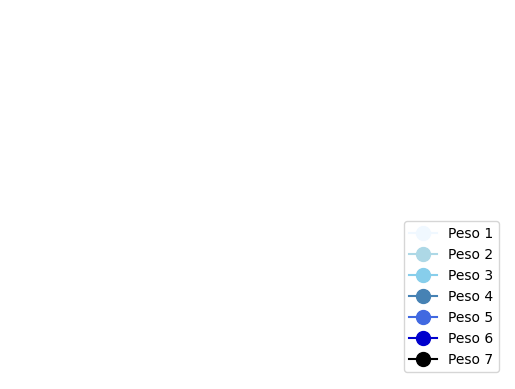

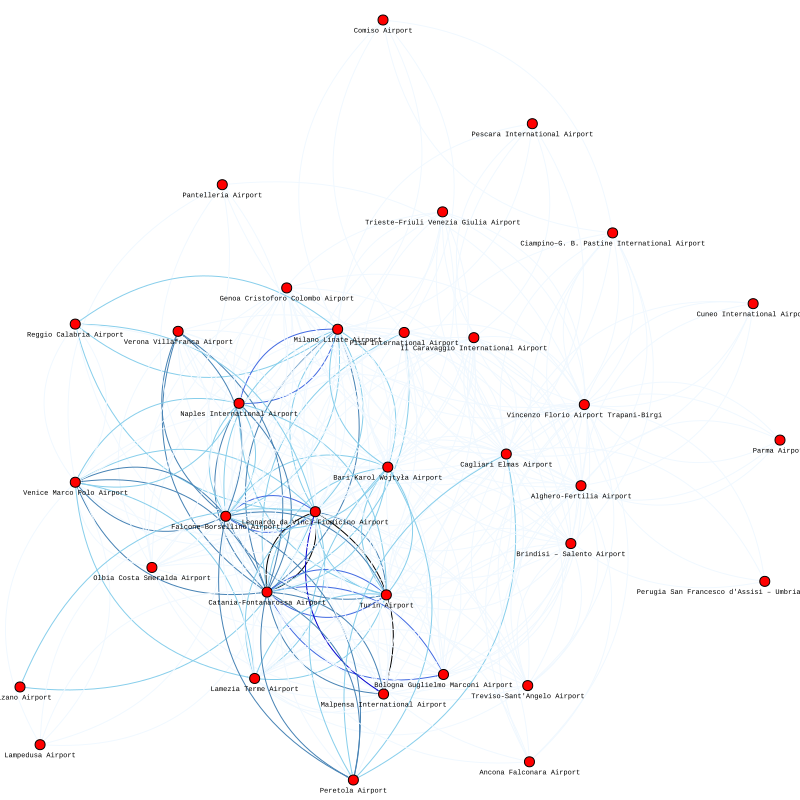

In [23]:
# Definisci una mappatura dei colori per i diversi pesi degli archi
import matplotlib.pyplot as plt

#print(df_merged['weight'].describe())
edge_colors = {
    1: '#f0f8ff',  # Azzurro molto chiaro
    2: '#add8e6',  # Azzurro chiaro
    3: '#87ceeb',  # Azzurro moderato
    4: '#4682b4',  # Blu acciaio
    5: '#4169e1',  # Blu reale
    6: '#0000cd',  # Blu medio
    7: 'black'     # Nero
}

color_legend = [
    (1, '#f0f8ff'),  # Azzurro molto chiaro
    (2, '#add8e6'),  # Azzurro chiaro
    (3, '#87ceeb'),  # Azzurro moderato
    (4, '#4682b4'),  # Blu acciaio
    (5, '#4169e1'),  # Blu reale
    (6, '#0000cd'),  # Blu medio
    (7, 'black')     # Nero
]

# Creiamo una legenda personalizzata
legend_elements = [plt.Line2D([0], [0], marker='o', color=color, label=f'Peso {weight}', markersize=10)
                   for weight, color in color_legend]

# Visualizziamo la legenda senza assi

plt.axis('off')  # Rimuove gli assi

plt.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1, 0))
plt.show()

# Mostrare il grafico
ig.plot(g
        , vertex_label=g.vs['name']
        , vertex_label_dist=1.5
        #, layout=g.layout('fruchterman_reingold')
        , bbox=(800, 800)
        , margin=20
        , vertex_size=10
        , edge_arrow_size=0.2
        , edge_curved=True
        #, edge_label=g.es['weight']
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        , edge_color=[edge_colors[weight] for weight in g.es['weight']]
        )


In [24]:
processed_nodes = set()

# Aggiungi attributi ai nodi senza duplicati
for _, row in df_merged.iterrows():
    # Nodo di partenza
    source_id = row['Source airport name']
    if source_id not in processed_nodes:  # Aggiungi attributi solo se non è stato già processato
        g.vs.find(name=source_id)['city'] = row['Source airport city']
        g.vs.find(name=source_id)['country'] = row['Source airport country']
        g.vs.find(name=source_id)['region'] = row['Source region']
        processed_nodes.add(source_id)  # Aggiungi il nodo al set dei nodi già processati

    # Nodo di arrivo
    destination_id = row['Destination airport name']
    if destination_id not in processed_nodes:
        g.vs.find(name=destination_id)['city'] = row['Destination airport city']
        g.vs.find(name=destination_id)['country'] = row['Destination airport country']
        g.vs.find(name=destination_id)['region'] = row['Destination region']
        processed_nodes.add(destination_id)  # Aggiungi anche questo nodo al set

In [25]:
for node in g.vs:
    # Usa 'attributes()' per ottenere tutti gli attributi del nodo
    attributes = node.attributes()
    print(f"Nodo {node['name']} ha attributi: {attributes}")

Nodo Brindisi – Salento Airport ha attributi: {'name': 'Brindisi – Salento Airport', 'city': 'Brindisi', 'country': 'Italy', 'region': 'Puglia'}
Nodo Leonardo da Vinci–Fiumicino Airport ha attributi: {'name': 'Leonardo da Vinci–Fiumicino Airport', 'city': 'Rome', 'country': 'Italy', 'region': 'Lazio'}
Nodo Naples International Airport ha attributi: {'name': 'Naples International Airport', 'city': 'Naples', 'country': 'Italy', 'region': 'Campania'}
Nodo Olbia Costa Smeralda Airport ha attributi: {'name': 'Olbia Costa Smeralda Airport', 'city': 'Olbia', 'country': 'Italy', 'region': 'Sardegna'}
Nodo Bologna Guglielmo Marconi Airport ha attributi: {'name': 'Bologna Guglielmo Marconi Airport', 'city': 'Bologna', 'country': 'Italy', 'region': 'Emilia-Romagna'}
Nodo Ancona Falconara Airport ha attributi: {'name': 'Ancona Falconara Airport', 'city': 'Ancona', 'country': 'Italy', 'region': 'Marche'}
Nodo Bari Karol Wojtyła Airport ha attributi: {'name': 'Bari Karol Wojtyła Airport', 'city': 'B

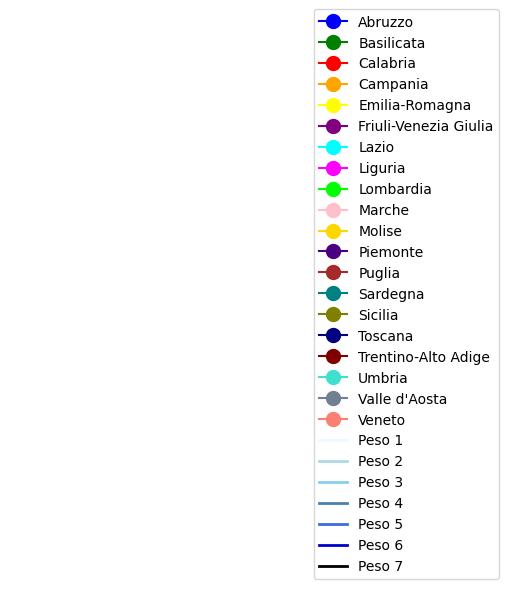

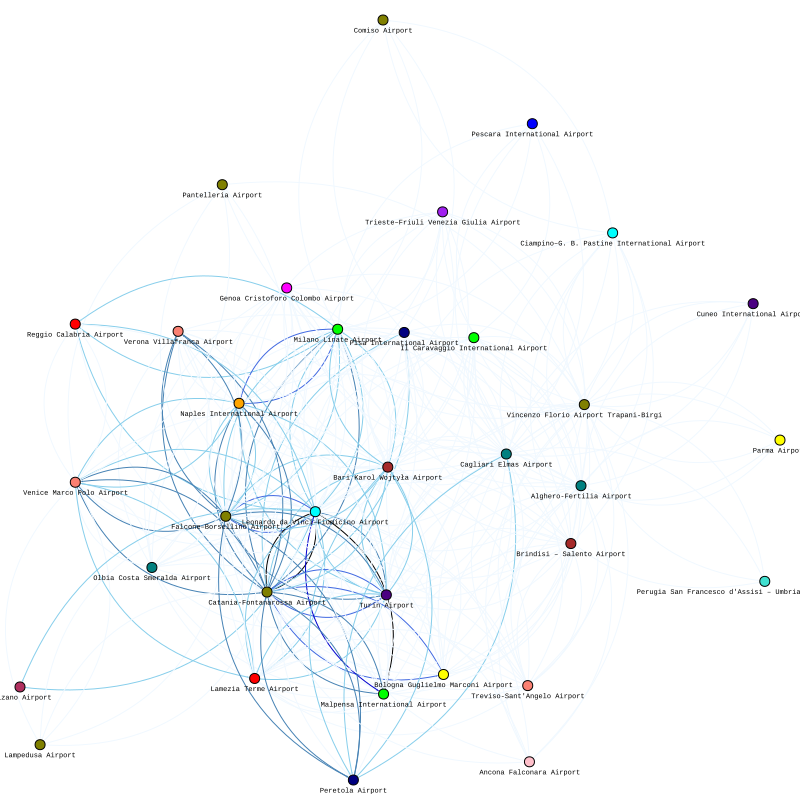

In [26]:
import matplotlib.pyplot as plt
import igraph as ig

import matplotlib.pyplot as plt

# Mappatura dei colori per le regioni italiane
region_colors = {
    'Abruzzo': 'blue',
    'Basilicata': 'green',
    'Calabria': 'red',
    'Campania': 'orange',
    'Emilia-Romagna': 'yellow',
    'Friuli-Venezia Giulia': 'purple',
    'Lazio': 'cyan',
    'Liguria': 'magenta',
    'Lombardia': 'lime',
    'Marche': 'pink',
    'Molise': 'gold',
    'Piemonte': 'indigo',
    'Puglia': 'brown',
    'Sardegna': 'teal',
    'Sicilia': 'olive',
    'Toscana': 'navy',
    'Trentino-Alto Adige': 'maroon',
    'Umbria': 'turquoise',
    "Valle d'Aosta": 'slategray',
    'Veneto': 'salmon'
}

edge_colors = {
    1: '#f0f8ff',  # Azzurro molto chiaro
    2: '#add8e6',  # Azzurro chiaro
    3: '#87ceeb',  # Azzurro moderato
    4: '#4682b4',  # Blu acciaio
    5: '#4169e1',  # Blu reale
    6: '#0000cd',  # Blu medio
    7: 'black'     # Nero
}


legend_elements = []

# Aggiungere elementi alla legenda per i colori dei nodi
for region, color in region_colors.items():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, label=region, markersize=10))

# Aggiungere elementi alla legenda per i colori degli archi
for weight, color in edge_colors.items():
    legend_elements.append(plt.Line2D([0], [0], color=color, label=f'Peso {weight}', linewidth=2))

# Creare una figura vuota
fig, ax = plt.subplots()

# Nascondere gli assi
ax.axis('off')

# Aggiungere la legenda al grafico
ax.legend(handles=legend_elements, loc='lower right')

# Mostrare la legenda
plt.show()



edge_colors = {
    1: '#f0f8ff',  # Azzurro molto chiaro
    2: '#add8e6',  # Azzurro chiaro
    3: '#87ceeb',  # Azzurro moderato
    4: '#4682b4',  # Blu acciaio
    5: '#4169e1',  # Blu reale
    6: '#0000cd',  # Blu medio
    7: 'black'   # Grigio ardesia scuro
}


# Mappatura dei colori per le regioni italiane
region_colors = {
    'Abruzzo': 'blue',
    'Basilicata': 'green',
    'Calabria': 'red',
    'Campania': 'orange',
    'Emilia-Romagna': 'yellow',
    'Friuli-Venezia Giulia': 'purple',
    'Lazio': 'cyan',
    'Liguria': 'magenta',
    'Lombardia': 'lime',
    'Marche': 'pink',
    'Molise': 'gold',
    'Piemonte': 'indigo',
    'Puglia': 'brown',
    'Sardegna': 'teal',
    'Sicilia': 'olive',
    'Toscana': 'navy',
    'Trentino-Alto Adige': 'maroon',
    'Umbria': 'turquoise',
    "Valle d'Aosta": 'slategray',
    'Veneto': 'salmon'
}

# Estrai le regioni dei nodi dal grafo
node_regions = g.vs['region']  # Supponendo che 'region' sia l'attributo che contiene le regioni dei nodi

# Assegna un colore ai nodi basato sulla regione
node_colors = [region_colors[region] for region in node_regions]

# Disegna il grafico su questi assi

ig.plot(g
        , vertex_label=g.vs['name']
        , vertex_label_dist=1.5
        #, layout=g.layout('fruchterman_reingold')
        , bbox=(800, 800)
        , margin=20
        , vertex_size=10
        , edge_arrow_size=0.2
        , edge_curved=True
        #, edge_label=g.es['weight']
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        , edge_color=[edge_colors[weight] for weight in g.es['weight']]
        ,vertex_color=node_colors
        )


Misure di **Centralità**

Grado

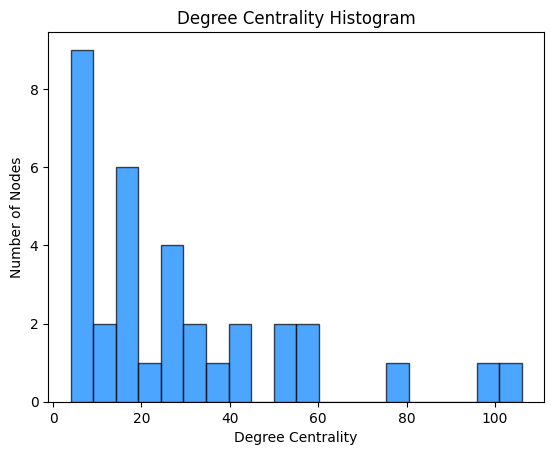

In [27]:
#grado, considerando i pesi
degree_sequence = g.strength(mode = 'all', weights='weight')

# Visualizza l'istogramma del conteggio dei gradi
plt.hist(degree_sequence, bins=20, alpha=0.7, color='#007FFF', edgecolor='black')
plt.xlabel('Degree Centrality')
plt.ylabel('Number of Nodes')
plt.title('Degree Centrality Histogram')
plt.grid(False)

plt.show()


In [28]:
# Ottieni i nomi dei nodi
nomi_nodi = g.vs["name"]

# Creazione della struttura dati (dizionario) per salvare nome del nodo e grado
struttura_dati = {}

# Associazione di nome del nodo al suo grado nel dizionario
for nome, grado in zip(nomi_nodi, degree_sequence):
    struttura_dati[nome] = grado

struttura_dati_ordinata_g = sorted(struttura_dati.items(), key=lambda item: item[1], reverse=True)
nomi_nodi_ordinati_g = [item[0] for item in struttura_dati_ordinata_g]

# Stampa dei nomi dei nodi ordinati
print("Nomi dei nodi ordinati per grado decrescente:")
for nodo in nomi_nodi_ordinati_g:
    print(nodo)
    #print(struttura_dati[nodo])
print(struttura_dati)

Nomi dei nodi ordinati per grado decrescente:
Catania-Fontanarossa Airport
Leonardo da Vinci–Fiumicino Airport
Falcone–Borsellino Airport
Milano Linate Airport
Turin Airport
Bari Karol Wojtyła Airport
Naples International Airport
Cagliari Elmas Airport
Venice Marco Polo Airport
Malpensa International Airport
Lamezia Terme Airport
Peretola Airport
Bologna Guglielmo Marconi Airport
Vincenzo Florio Airport Trapani-Birgi
Verona Villafranca Airport
Alghero-Fertilia Airport
Pisa International Airport
Brindisi – Salento Airport
Olbia Costa Smeralda Airport
Il Caravaggio International Airport
Genoa Cristoforo Colombo Airport
Reggio Calabria Airport
Treviso-Sant'Angelo Airport
Trieste–Friuli Venezia Giulia Airport
Ciampino–G. B. Pastine International Airport
Ancona Falconara Airport
Bolzano Airport
Comiso Airport
Pescara International Airport
Lampedusa Airport
Pantelleria Airport
Cuneo International Airport
Parma Airport
Perugia San Francesco d'Assisi – Umbria International Airport
{'Brindisi –

Betweenness

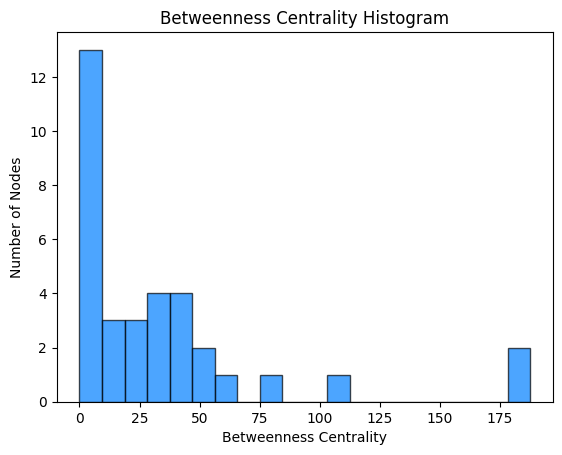

In [29]:
# Calcolo della betweenness con igraph
betweenness = g.betweenness(directed=True, weights= 'weight')

# Creazione dell'istogramma
plt.hist(betweenness, bins=20, alpha=0.7, color='#007FFF', edgecolor='black')
plt.xlabel('Betweenness Centrality')
plt.ylabel('Number of Nodes')
plt.title('Betweenness Centrality Histogram')
#plt.grid(False)
plt.show()

In [30]:
# Ottieni i nomi dei nodi
nomi_nodi = g.vs["name"]

# Creazione della struttura dati (dizionario) per salvare nome del nodo e grado
struttura_dati = {}

# Associazione di nome del nodo al suo grado nel dizionario
for nome, betweenne in zip(nomi_nodi, betweenness):
    struttura_dati[nome] = betweenne

struttura_dati_ordinata_b = sorted(struttura_dati.items(), key=lambda item: item[1], reverse=True)
nomi_nodi_ordinati_b = [item[0] for item in struttura_dati_ordinata_b]

# Stampa dei nomi dei nodi ordinati
print("Nomi dei nodi ordinati per grado decrescente:")
for nodo in nomi_nodi_ordinati_b:
    print(nodo)
    #print(struttura_dati[nodo])

Nomi dei nodi ordinati per grado decrescente:
Cagliari Elmas Airport
Leonardo da Vinci–Fiumicino Airport
Vincenzo Florio Airport Trapani-Birgi
Alghero-Fertilia Airport
Bari Karol Wojtyła Airport
Venice Marco Polo Airport
Pisa International Airport
Falcone–Borsellino Airport
Turin Airport
Olbia Costa Smeralda Airport
Il Caravaggio International Airport
Milano Linate Airport
Genoa Cristoforo Colombo Airport
Bologna Guglielmo Marconi Airport
Brindisi – Salento Airport
Treviso-Sant'Angelo Airport
Malpensa International Airport
Catania-Fontanarossa Airport
Ciampino–G. B. Pastine International Airport
Lamezia Terme Airport
Ancona Falconara Airport
Trieste–Friuli Venezia Giulia Airport
Pantelleria Airport
Lampedusa Airport
Naples International Airport
Reggio Calabria Airport
Verona Villafranca Airport
Comiso Airport
Pescara International Airport
Cuneo International Airport
Parma Airport
Peretola Airport
Bolzano Airport
Perugia San Francesco d'Assisi – Umbria International Airport


Reciprocità e Assortatività

In [31]:
reciprocity = g.reciprocity()
print(f"Reciprocity: {reciprocity}")

degree_assortativity = g.assortativity_degree()
print(f"Degree Assortativity: {degree_assortativity}")

Reciprocity: 0.9933774834437086
Degree Assortativity: -0.3420093403367353


Analisi della rete

In [32]:
# Trova tutte le componenti connesse
components = g.connected_components()
# Conta il numero di nodi in ogni componente
component_sizes = [len(component) for component in components]

# Stampa le dimensioni di ogni componente
for i, size in enumerate(component_sizes):
    print(f"Component {i+1} has {size} nodes")



Component 1 has 34 nodes


In [33]:
# Trova la giant component massima
giant_component = components.giant()

# Calcola il diametro della giant component massima
diameter = giant_component.diameter()

print(f"Il diametro della giant component massima è: {diameter}")

Il diametro della giant component massima è: 4


In [34]:
# Calcola la lunghezza media dei cammini
avg_path_length = g.average_path_length()

print("Lunghezza media dei cammini:", avg_path_length)

Lunghezza media dei cammini: 1.86096256684492


In [35]:
# Funzione per calcolare l'efficienza globale di un grafo
def calculate_global_efficiency(graph):
    n = len(graph.vs)
    if n < 2:
        return 0
    inv_distances = []
    shortest_paths = graph.shortest_paths()
    for row in shortest_paths:
        inv_distances.extend([1/d for d in row if d > 0])
    efficiency = sum(inv_distances) / (n * (n - 1))
    return efficiency

# Calcola l'efficienza globale del grafo
efficiency = calculate_global_efficiency(g)

print("Efficienza globale:", efficiency)

Efficienza globale: 0.6133392751039821


<ipython-input-35-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


Attacchi alla rete

In [36]:
import random
import numpy as np

def remove_edges_of_node(graph, node_name):
    node = graph.vs.find(name=node_name)
    edges_from_source = graph.es.select(_source=node.index)
    edges_from_target = graph.es.select(_target=node.index)
    edges_to_remove_indices = [edge.index for edge in edges_from_source] + [edge.index for edge in edges_from_target]
    graph.delete_edges(edges_to_remove_indices)

def simulate_attack(graph, num_attacks, nodi_ordinati=[]):
    original_graph = graph.copy()
    initial_metrics = {
        'giant_component_size': [],
        'edge_count': [],
        'diameter': [],
        'avg_path_length': [],
        'efficiency': [],
        'nodes_removed_percentage': []
    }

    initial_giant_component = graph.components().giant()
    initial_giant_component_size = len(initial_giant_component.vs)
    initial_edge_count = sum(edge['weight'] for edge in graph.es)
    initial_diameter = initial_giant_component.diameter()
    initial_avg_path_length = graph.average_path_length()
    initial_efficiency = calculate_global_efficiency(graph)

    initial_metrics['giant_component_size'].append(initial_giant_component_size)
    initial_metrics['edge_count'].append(initial_edge_count)
    initial_metrics['diameter'].append(initial_diameter)
    initial_metrics['avg_path_length'].append(initial_avg_path_length)
    initial_metrics['efficiency'].append(initial_efficiency)
    initial_metrics['nodes_removed_percentage'].append(0)  # Inizialmente, nessun nodo è stato rimosso

    removed_nodes = []
    removed_node_names = []

    for attack in range(num_attacks):
        if len(nodi_ordinati) > 0:
            node_to_remove = nodi_ordinati.pop(0)
        else:
            if len(graph.vs) == 0:
                break
            node_to_remove = random.choice(graph.vs)['name']

        removed_nodes.append(node_to_remove)
        removed_node_names.append(node_to_remove)
        graph.delete_vertices(node_to_remove)
        remove_edges_of_node(original_graph, node_to_remove)

        if len(graph.vs) == 0:
            break

        giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
        giant_component_size = len(giant_component.vs)
        edge_count = sum(edge['weight'] for edge in graph.es)
        diameter = giant_component.diameter() if giant_component_size > 1 else 0
        avg_path_length = graph.average_path_length() if len(graph.vs) > 1 else 0
        efficiency = calculate_global_efficiency(graph)

        initial_metrics['giant_component_size'].append(giant_component_size)
        initial_metrics['edge_count'].append(edge_count)
        initial_metrics['diameter'].append(diameter)
        initial_metrics['avg_path_length'].append(avg_path_length)
        initial_metrics['efficiency'].append(efficiency)
        nodes_removed_percentage = (len(removed_nodes) / initial_giant_component_size) * 100
        initial_metrics['nodes_removed_percentage'].append(nodes_removed_percentage)

    #countryg = graph.vs["country"]
    italyg = graph.vs["name"]
    final_giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
    #country_values = final_giant_component.vs["country"]
    name_values = final_giant_component.vs["name"]
    not_in_name_italy = [name for name in italyg if name not in name_values]
    #not_in_country_values = [country for country in countryg if country not in country_values]

    original_graph.vs["color"] = "white"
    for v in original_graph.vs:
        if v["name"] in removed_node_names:
            v["color"] = "red"
        elif v["name"] in name_values:
            v["color"] = "green"

    layout = original_graph.layout("fr")

    return {
        "graph": original_graph,
        "removed_nodes": removed_nodes,
        "metrics": initial_metrics,
        "lista aereoporti italiani non presenti nella giant component": not_in_name_italy
    }

Casuali

In [37]:
# Simula un attacco rimuovendo dei nodi
results = simulate_attack(g.copy(), 15,[])
metrics_random = results["metrics"]
print(results)

{'graph': <igraph.Graph object at 0x792035d1b140>, 'removed_nodes': ['Bari Karol Wojtyła Airport', 'Ancona Falconara Airport', 'Ciampino–G. B. Pastine International Airport', 'Turin Airport', 'Comiso Airport', 'Bolzano Airport', 'Reggio Calabria Airport', 'Parma Airport', 'Falcone–Borsellino Airport', "Perugia San Francesco d'Assisi – Umbria International Airport", 'Catania-Fontanarossa Airport', 'Verona Villafranca Airport', 'Trieste–Friuli Venezia Giulia Airport', 'Cuneo International Airport', 'Pescara International Airport'], 'metrics': {'giant_component_size': [34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19], 'edge_count': [496, 442, 434, 424, 375, 371, 365, 351, 345, 282, 278, 191, 183, 173, 167, 161], 'diameter': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3], 'avg_path_length': [1.86096256684492, 1.8920454545454546, 1.8891129032258065, 1.8731182795698924, 1.889655172413793, 1.8522167487684729, 1.82010582010582, 1.7977207977207976, 1.7661538461538462, 1.8016666

<ipython-input-35-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


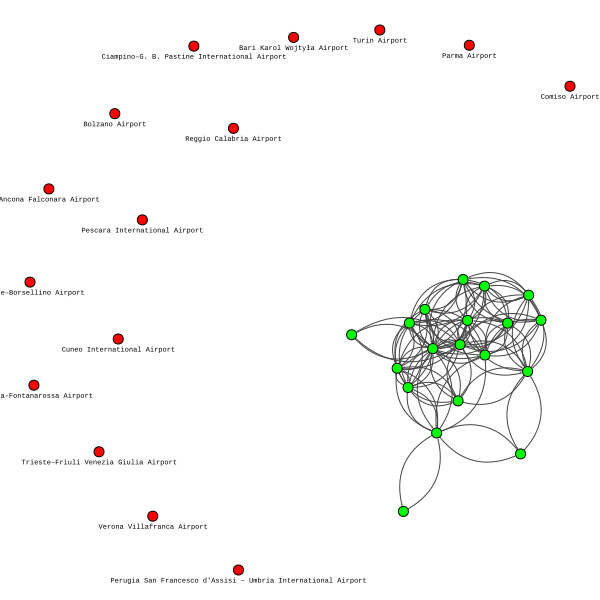

In [38]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

Mirati

In [39]:
# Simula un attacco rimuovendo dei nodi secondo l'ordine del grado
results = simulate_attack(g.copy(), 15, nomi_nodi_ordinati_g)
metrics_ordered_g = results["metrics"]
print(results)


{'graph': <igraph.Graph object at 0x792035d1be40>, 'removed_nodes': ['Catania-Fontanarossa Airport', 'Leonardo da Vinci–Fiumicino Airport', 'Falcone–Borsellino Airport', 'Milano Linate Airport', 'Turin Airport', 'Bari Karol Wojtyła Airport', 'Naples International Airport', 'Cagliari Elmas Airport', 'Venice Marco Polo Airport', 'Malpensa International Airport', 'Lamezia Terme Airport', 'Peretola Airport', 'Bologna Guglielmo Marconi Airport', 'Vincenzo Florio Airport Trapani-Birgi', 'Verona Villafranca Airport'], 'metrics': {'giant_component_size': [34, 33, 31, 30, 29, 28, 27, 26, 24, 21, 20, 19, 19, 18, 12, 12], 'edge_count': [496, 390, 306, 240, 202, 172, 144, 126, 94, 80, 72, 64, 64, 56, 34, 32], 'diameter': [4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 4, 4], 'avg_path_length': [1.86096256684492, 1.8806818181818181, 1.950537634408602, 2.013793103448276, 2.0689655172413794, 2.121693121693122, 2.1823361823361824, 2.246153846153846, 2.3949275362318843, 2.2476190476190476, 2.257894736842105

<ipython-input-35-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


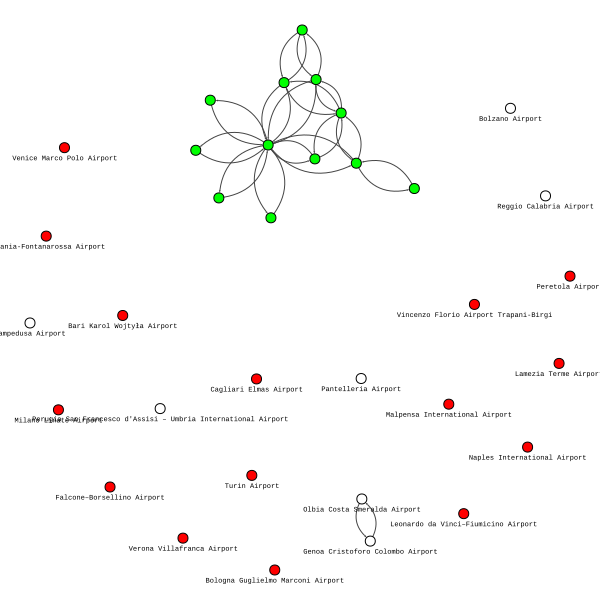

In [40]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

In [41]:
# Simula un attacco rimuovendo dei nodi secondo l'ordine della betweenness
results = simulate_attack(g.copy(), 15, nomi_nodi_ordinati_b)
metrics_ordered_b = results["metrics"]
print(results)


<ipython-input-35-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


{'graph': <igraph.Graph object at 0x792035d1af40>, 'removed_nodes': ['Cagliari Elmas Airport', 'Leonardo da Vinci–Fiumicino Airport', 'Vincenzo Florio Airport Trapani-Birgi', 'Alghero-Fertilia Airport', 'Bari Karol Wojtyła Airport', 'Venice Marco Polo Airport', 'Pisa International Airport', 'Falcone–Borsellino Airport', 'Turin Airport', 'Olbia Costa Smeralda Airport', 'Il Caravaggio International Airport', 'Milano Linate Airport', 'Genoa Cristoforo Colombo Airport', 'Bologna Guglielmo Marconi Airport', 'Brindisi – Salento Airport'], 'metrics': {'giant_component_size': [34, 33, 31, 29, 26, 25, 24, 23, 21, 20, 19, 18, 15, 14, 13, 10], 'edge_count': [496, 454, 358, 332, 308, 258, 222, 208, 157, 129, 117, 109, 75, 71, 57, 51], 'diameter': [4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 3], 'avg_path_length': [1.86096256684492, 1.9526515151515151, 2.018279569892473, 2.023399014778325, 1.9184615384615384, 2.025, 2.0615942028985508, 2.0711462450592886, 2.085714285714286, 2.1157894736842104, 2.1

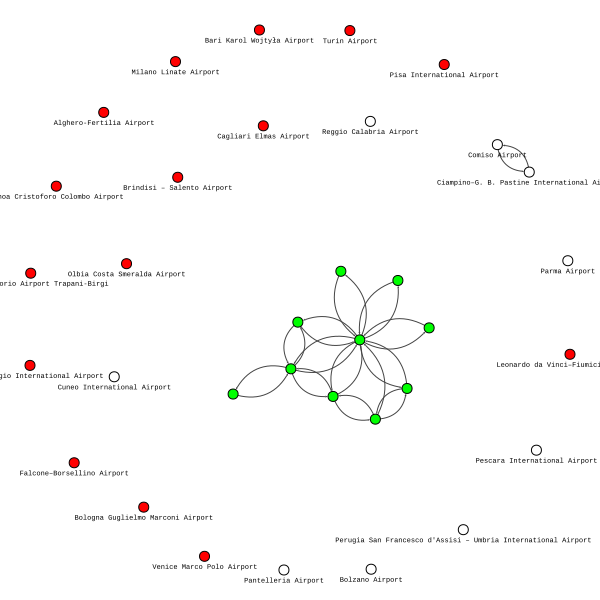

In [42]:

vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

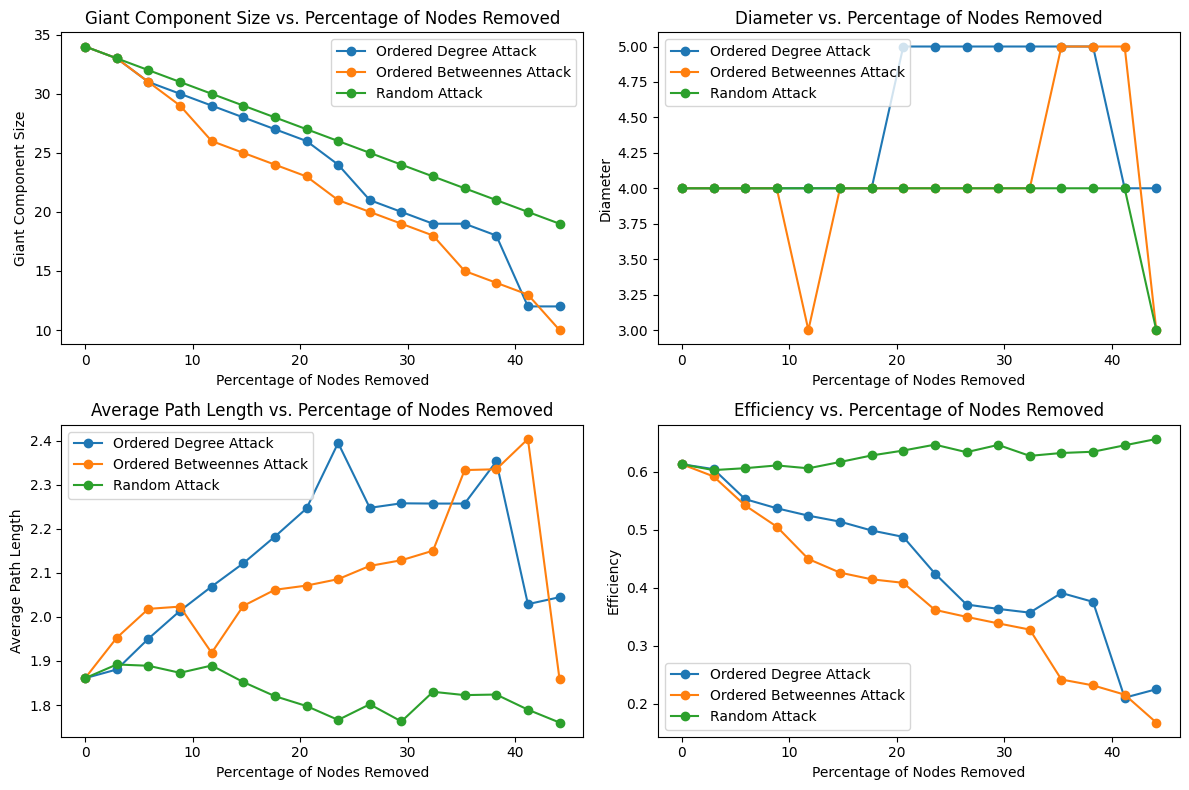

In [43]:
# Creazione dei grafici
import matplotlib.pyplot as plt

# Creazione dei grafici
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['giant_component_size'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['giant_component_size'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['giant_component_size'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Giant Component Size')
plt.title('Giant Component Size vs. Percentage of Nodes Removed')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['diameter'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['diameter'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['diameter'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Diameter')
plt.title('Diameter vs. Percentage of Nodes Removed')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['avg_path_length'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['avg_path_length'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['avg_path_length'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Average Path Length')
plt.title('Average Path Length vs. Percentage of Nodes Removed')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(metrics_ordered_g['nodes_removed_percentage'], metrics_ordered_g['efficiency'], marker='o', label='Ordered Degree Attack')
plt.plot(metrics_ordered_b['nodes_removed_percentage'], metrics_ordered_b['efficiency'], marker='o', label='Ordered Betweennes Attack')
plt.plot(metrics_random['nodes_removed_percentage'], metrics_random['efficiency'], marker='o', label='Random Attack')
plt.xlabel('Percentage of Nodes Removed')
plt.ylabel('Efficiency')
plt.title('Efficiency vs. Percentage of Nodes Removed')
plt.legend()

plt.tight_layout()
plt.show()

**Sezione sulle compagnie aeree**

In [44]:
#import del db airlines, per avere informazioni sulle compagnie aeree
df_airlines = pd.read_csv("drive/MyDrive/Progetto Data Analytics/airlines.csv")
#df_airlines

In [45]:
# Tieni solo le colonne 'Airline ID' e 'Name'
df_airlines = df_airlines[['Airline ID', 'Name']]
#df_airlines

In [46]:
df_routes_edge = df_routes_ori.loc[:, ['Airline ID', 'Source airport', 'Source airport ID', 'Destination airport', 'Destination airport ID']]
#df_routes_edge.head()

In [47]:
# Eliminiamo i record con 'Source Airport ID' uguale a '\N'
df_routes_edge = df_routes_edge[df_routes_edge['Source airport ID'] != '\\N']

# Eliminiamo i record con 'Destination Airport ID' uguale a '\N'
df_routes_edge = df_routes_edge[df_routes_edge['Destination airport ID'] != '\\N']

# Eliminiamo i record con 'Destination Airport ID' uguale a '\N'
df_routes_edge = df_routes_edge[df_routes_edge['Airline ID'] != '\\N']

# Trasformiamo la colonna 'Destination Airport ID' in tipo int64
df_routes_edge['Airline ID'] = df_routes_edge['Airline ID'].astype('int64')

# Trasformiamo la colonna 'Source Airport ID' in tipo int64
df_routes_edge['Source airport ID'] = df_routes_edge['Source airport ID'].astype('int64')

# Trasformiamo la colonna 'Destination Airport ID' in tipo int64
df_routes_edge['Destination airport ID'] = df_routes_edge['Destination airport ID'].astype('int64')

Creazione di un unico dataset

In [48]:
# Eseguiamo l'inner join sugli aeroporti di partenza
df_merged_edge = pd.merge(df_routes_edge, df_airports, left_on='Source airport ID', right_on='Airport ID', how='inner')
#df_merged_edge

In [49]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged_edge = df_merged_edge.drop(columns=['Airport ID'])

# Rinominiamo le colonne, in vista della seconda merge
df_merged_edge = df_merged_edge.rename(columns={
    'Name': 'Source airport name',
    'City': 'Source airport city',
    'Country': 'Source airport country'
})

#df_merged_edge.head()

In [50]:
# Eseguiamo l'inner join sugli aeroporti di destinazione
df_merged_edge = pd.merge(df_merged_edge, df_airports, left_on='Destination airport ID', right_on='Airport ID', how='inner')
#df_merged_edge

In [51]:
# Rimuoviamo la colonna 'Airport ID' da df_merged, in quanto ripetizione di source airport id
df_merged_edge = df_merged_edge.drop(columns=['Airport ID'])

# Rinominiamo le colonne
df_merged_edge = df_merged_edge.rename(columns={
    'Name': 'Destination airport name',
    'City': 'Destination airport city',
    'Country': 'Destination airport country'
})

#df_merged_edge

In [52]:
# Eseguiamo l'inner join sulle compagnie aeree
df_merged_edge = pd.merge(df_merged_edge, df_airlines, left_on='Airline ID', right_on='Airline ID', how='inner')
#df_merged_edge

In [53]:
df_merged_edge = df_merged_edge.rename(columns={
    'Name': 'Airline name'
})
df_merged_edge

,Airline ID,Source airport,Source airport ID,Destination airport,Destination airport ID,Source airport name,Source airport city,Source airport country,Destination airport name,Destination airport city,Destination airport country,Airline name
0,596,BDS,1506,FCO,1555,Brindisi – Salento Airport,Brindisi,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,Alitalia
1,596,NAP,1561,FCO,1555,Naples International Airport,Naples,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,Alitalia
2,596,BLQ,1538,FCO,1555,Bologna Guglielmo Marconi Airport,Bologna,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,Alitalia
3,596,AOI,4309,FCO,1555,Ancona Falconara Airport,Ancona,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,Alitalia
4,596,BRI,1501,FCO,1555,Bari Karol Wojtyła Airport,Bari,Italy,Leonardo da Vinci–Fiumicino Airport,Rome,Italy,Alitalia
...,...,...,...,...,...,...,...,...,...,...,...,...
420,20577,VCE,1551,REG,1514,Venice Marco Polo Airport,Venice,Italy,Reggio Calabria Airport,Reggio Calabria,Italy,VOLOTEA Airways
421,20577,VCE,1551,PNL,1511,Venice Marco Polo Airport,Venice,Italy,Pantelleria Airport,Pantelleria,Italy,VOLOTEA Airways
422,5039,PMO,1512,CTA,1509,Falcone–Borsellino Airport,Palermo,Italy,Catania-Fontanarossa Airport,Catania,Italy,Transavia Holland
423,5039,SUF,1508,CTA,1509,Lamezia Terme Airport,Lamezia,Italy,Catania-Fontanarossa Airport,Catania,Italy,Transavia Holland


In [54]:
names = df_merged_edge['Airline name']
airline_counts = names.value_counts()
print(airline_counts)

#sum(name_counts)

Airline name
Ryanair                     128
Alitalia                    100
Meridiana                    42
VOLOTEA Airways              40
Air One                      30
easyJet                      28
Blue Panorama Airlines       16
Iberia Airlines              10
Formosa Airlines             10
Flybaboo                     10
Ethiopian Airlines            2
Transavia Holland             2
Excel Airways                 2
Air Italy                     2
Korean Air                    1
KLM Royal Dutch Airlines      1
Transavia France              1
Name: count, dtype: int64


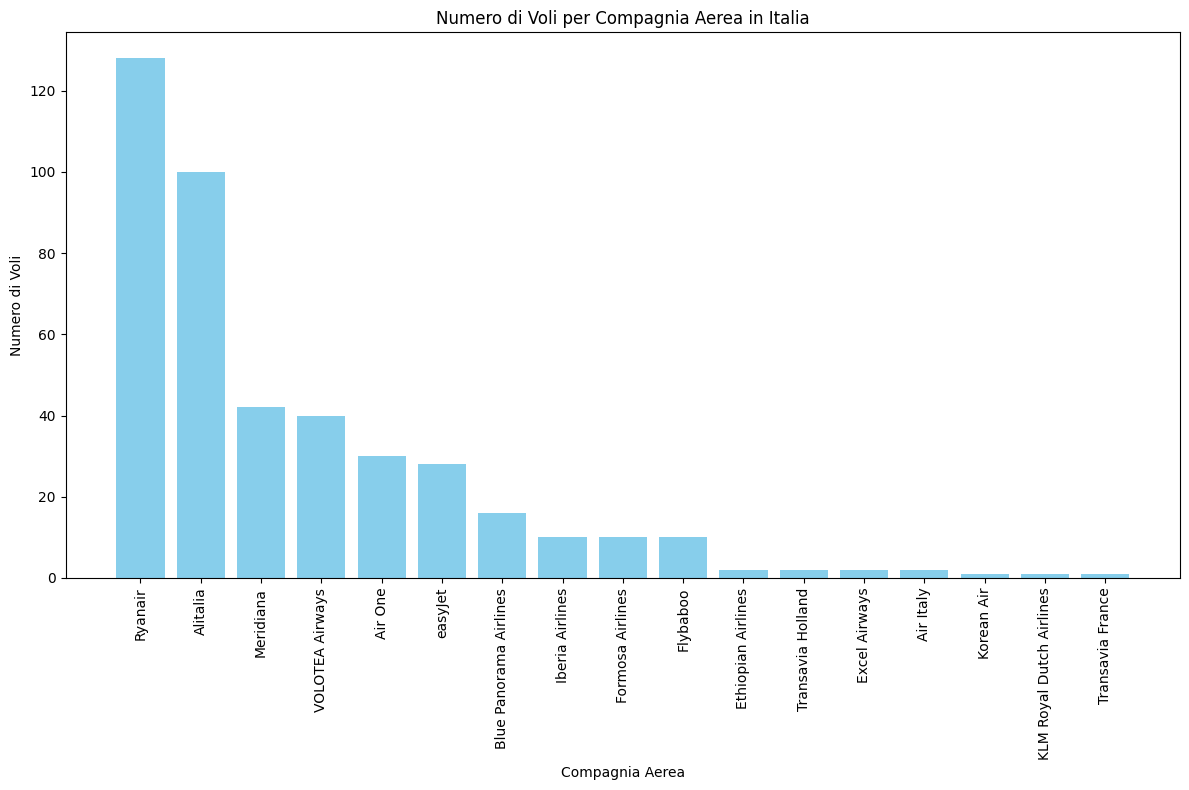

In [55]:
import matplotlib.pyplot as plt

# Dati delle compagnie aeree e numero di voli
compagnie_aeree = [
    'Ryanair', 'Alitalia', 'Meridiana', 'VOLOTEA Airways', 'Air One',
    'easyJet', 'Blue Panorama Airlines', 'Iberia Airlines',
    'Formosa Airlines', 'Flybaboo', 'Ethiopian Airlines',
    'Transavia Holland', 'Excel Airways', 'Air Italy', 'Korean Air',
    'KLM Royal Dutch Airlines', 'Transavia France'
]

numero_voli = [
    128, 100, 42, 40, 30, 28, 16, 10, 10, 10, 2, 2, 2, 2, 1, 1, 1
]

# Creazione del grafico a barre
plt.figure(figsize=(12, 8))
plt.bar(compagnie_aeree, numero_voli, color='skyblue')

# Ruotare i nomi delle compagnie aeree sull'asse x
plt.xticks(rotation=90)

# Etichettare gli assi
plt.xlabel('Compagnia Aerea')
plt.ylabel('Numero di Voli')
plt.title('Numero di Voli per Compagnia Aerea in Italia')

# Visualizzare il grafico
plt.tight_layout()
plt.show()


In [56]:
# Ottieni i nomi delle compagnie aeree
names = df_merged_edge['Airline name']
# Conta la frequenza di ciascun nome
airline_counts = names.value_counts()
# Crea un array dei nomi delle compagnie aeree ordinati in ordine decrescente di frequenza
ordered_airlines = airline_counts.index.tolist()

print(ordered_airlines)

['Ryanair', 'Alitalia', 'Meridiana', 'VOLOTEA Airways', 'Air One', 'easyJet', 'Blue Panorama Airlines', 'Iberia Airlines', 'Formosa Airlines', 'Flybaboo', 'Ethiopian Airlines', 'Transavia Holland', 'Excel Airways', 'Air Italy', 'Korean Air', 'KLM Royal Dutch Airlines', 'Transavia France']


Creazione del grafo

In [57]:
# Crea un grafo vuoto
g_airlines = ig.Graph(directed=True)

# Aggiungi nodi
nodi = pd.unique(df_merged_edge[['Source airport name', 'Destination airport name']].values.ravel('K'))
g_airlines.add_vertices(nodi)

# Aggiungi archi e pesi
for _, row in df_merged_edge.iterrows():
    source_id = row['Source airport name']
    dest_id = row['Destination airport name']
    g_airlines.add_edge(source_id, dest_id, Airline_name=row['Airline name'])

# Verifica gli archi con attributi 'None'
for edge in g_airlines.es:
    if edge['Airline_name'] is None:
        print(f"Arco con Airline_name None: {edge.source} -> {edge.target}")



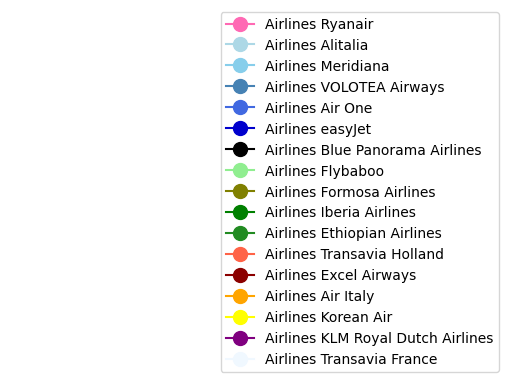

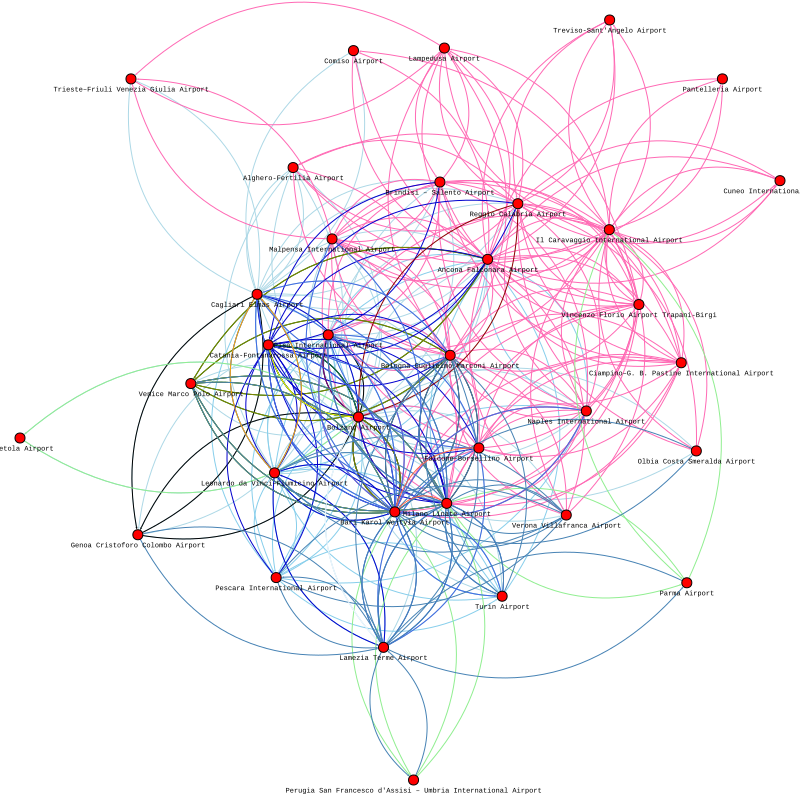

In [58]:
# Definisci una mappatura dei colori per i diversi pesi degli archi
import matplotlib.pyplot as plt


edge_colors = {
  'Transavia France'                 : '#f0f8ff', #Azzurro molto chiaro
  'Alitalia'                : '#add8e6', #Azzurro chiaro
  'Meridiana'               : '#87ceeb', #Azzurro moderato
  'VOLOTEA Airways'         : '#4682b4', #Blu acciaio
  'Air One'                 : '#4169e1', #Blu reale
  'easyJet'                 : '#0000cd', #Blu medio
  'Blue Panorama Airlines'  : '#000000', #Nero
  'Flybaboo'                : '#90ee90', #Verde chiaro
  'Formosa Airlines'        : '#808000', #Verde oliva
  'Iberia Airlines'         :'#008000', #Verde smeraldo
  'Ethiopian Airlines'      :'#228b22', #Verde bosco
  'Transavia Holland'       :'#ff6347', #Rosso chiaro
  'Excel Airways'           :'#8b0000', #Rosso scuro
  'Air Italy'               :'#ffa500', #Arancione
  'Korean Air'              :'#ffff00', #Giallo
  'KLM Royal Dutch Airlines':'#800080', #Viola
  'Ryanair'        :'#ff69b4' #Rosa
}

color_legend = [
    ('Ryanair'                 , '#ff69b4'),  # Rosa
    ('Alitalia'                , '#add8e6'),  # Azzurro chiaro
    ('Meridiana'               , '#87ceeb'),  # Azzurro moderato
    ('VOLOTEA Airways'         , '#4682b4'),  # Blu acciaio
    ('Air One'                 , '#4169e1'),  # Blu reale
    ('easyJet'                 , '#0000cd'),  # Blu medio
    ('Blue Panorama Airlines'  , '#000000'),  # Nero
    ('Flybaboo'                , '#90ee90'),  # Verde chiaro
    ('Formosa Airlines'        , '#808000'),  # Verde oliva
    ('Iberia Airlines'         , '#008000'),  # Verde smeraldo
    ('Ethiopian Airlines'      , '#228b22'),  # Verde bosco
    ('Transavia Holland'       , '#ff6347'),  # Rosso chiaro
    ('Excel Airways'           , '#8b0000'),  # Rosso scuro
    ('Air Italy'               , '#ffa500'),  # Arancione
    ('Korean Air'              , '#ffff00'),  # Giallo
    ('KLM Royal Dutch Airlines', '#800080'),  # Viola
    ('Transavia France'        , '#f0f8ff')  # Azzurro molto chiaro
]


# Creiamo una legenda personalizzata
legend_elements = [plt.Line2D([0], [0], marker='o', color=color, label=f'Airlines {name}', markersize=10)
                   for name, color in color_legend]

# Visualizziamo la legenda senza assi

plt.axis('off')  # Rimuove gli assi

plt.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1, 0))
plt.show()

# Mostrare il grafico
ig.plot(g_airlines
        , vertex_label=g.vs['name']
        , vertex_label_dist=1.5
        #, layout=g.layout('fruchterman_reingold')
        , bbox=(800, 800)
        , margin=20
        , vertex_size=10
        , edge_arrow_size=0.2
        , edge_curved=True
        #, edge_label=g.es['weight']
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        , edge_color=[edge_colors[name] for name in g_airlines.es['Airline_name']]
        )

In [59]:
tratte_uniche1 = set()
for edge in g_airlines.es:
    source = g_airlines.vs[edge.source]['name']
    dest = g_airlines.vs[edge.target]['name']
    tratte_uniche1.add((source, dest))

# Stampa tutte le tratte uniche
for tratta in tratte_uniche1:
    print(f"Tratta aerea: {tratta[0]} -> {tratta[1]}")

Tratta aerea: Il Caravaggio International Airport -> Bari Karol Wojtyła Airport
Tratta aerea: Catania-Fontanarossa Airport -> Malpensa International Airport
Tratta aerea: Cagliari Elmas Airport -> Milano Linate Airport
Tratta aerea: Milano Linate Airport -> Brindisi – Salento Airport
Tratta aerea: Alghero-Fertilia Airport -> Bologna Guglielmo Marconi Airport
Tratta aerea: Alghero-Fertilia Airport -> Treviso-Sant'Angelo Airport
Tratta aerea: Pisa International Airport -> Cagliari Elmas Airport
Tratta aerea: Il Caravaggio International Airport -> Alghero-Fertilia Airport
Tratta aerea: Turin Airport -> Brindisi – Salento Airport
Tratta aerea: Malpensa International Airport -> Falcone–Borsellino Airport
Tratta aerea: Vincenzo Florio Airport Trapani-Birgi -> Trieste–Friuli Venezia Giulia Airport
Tratta aerea: Ancona Falconara Airport -> Catania-Fontanarossa Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Bolzano Airport
Tratta aerea: Pantelleria Airport -> Venice Marco Polo Air

In [60]:
numero_tratte_uniche1 = len(tratte_uniche1)
numero_tratte_uniche1

302

Funzione per simulare attacchi agli archi

In [61]:
def simulate_edge_attack(graph, num_attacks, ordered_attributes=[]):
    initial_giant_component = graph.components().giant()
    initial_giant_component_size = len(initial_giant_component.vs)
    initial_edge_count = graph.ecount()
    initial_diameter = initial_giant_component.diameter()
    initial_avg_path_length = graph.average_path_length()
    initial_efficiency = calculate_global_efficiency(graph)

    metrics = {
        'giant_component_size': [initial_giant_component_size],
        'edge_count': [initial_edge_count],
        'diameter': [initial_diameter],
        'avg_path_length': [initial_avg_path_length],
        'efficiency': [initial_efficiency],
        'edges_removed': [0]
    }

    removed_edges = []
    unique_airlines = list(set(graph.es["Airline_name"]))

    if ordered_attributes:
        for attribute in ordered_attributes:
            if num_attacks <= 0 or len(unique_airlines) == 0:
                break
            if attribute in unique_airlines:
                unique_airlines.remove(attribute)
                edges_to_remove = [e.index for e in graph.es if e["Airline_name"] == attribute]
                removed_edges.append(attribute)
                graph.delete_edges(edges_to_remove)
                num_attacks -= 1

                giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
                giant_component_size = len(giant_component.vs)
                edge_count = graph.ecount()
                diameter = giant_component.diameter() if giant_component_size > 1 else 0
                avg_path_length = graph.average_path_length() if len(graph.vs) > 1 else 0
                efficiency = calculate_global_efficiency(graph)

                metrics['giant_component_size'].append(giant_component_size)
                metrics['edge_count'].append(edge_count)
                metrics['diameter'].append(diameter)
                metrics['avg_path_length'].append(avg_path_length)
                metrics['efficiency'].append(efficiency)
                metrics['edges_removed'].append(len(removed_edges))

    else:
        for _ in range(num_attacks):
            if len(unique_airlines) == 0:
                break
            airline_to_remove = random.choice(unique_airlines)
            unique_airlines.remove(airline_to_remove)
            edges_to_remove = [e.index for e in graph.es if e["Airline_name"] == airline_to_remove]
            removed_edges.append(airline_to_remove)
            graph.delete_edges(edges_to_remove)

            giant_component = graph.components().giant() if len(graph.components()) > 0 else ig.Graph()
            giant_component_size = len(giant_component.vs)
            edge_count = graph.ecount()
            diameter = giant_component.diameter() if giant_component_size > 1 else 0
            avg_path_length = graph.average_path_length() if len(graph.vs) > 1 else 0
            efficiency = calculate_global_efficiency(graph)

            metrics['giant_component_size'].append(giant_component_size)
            metrics['edge_count'].append(edge_count)
            metrics['diameter'].append(diameter)
            metrics['avg_path_length'].append(avg_path_length)
            metrics['efficiency'].append(efficiency)
            metrics['edges_removed'].append(len(removed_edges))

    graph.vs["color"] = "white"
    name_values = giant_component.vs["name"]
    for v in graph.vs:
        if v["name"] in name_values:
            v["color"] = "green"

    layout = graph.layout("fr")

    return {
        "graph": graph,
        "removed_edges": removed_edges,
        "metrics": metrics
    }

Attacco Casuale

In [62]:
# Simula un attacco rimuovendo 2 attributi casuali
results = simulate_edge_attack(g_airlines.copy(), 5)
metrics_edge_random = results["metrics"]
print("Attacco casuale:", results)


Attacco casuale: {'graph': <igraph.Graph object at 0x7920316ac240>, 'removed_edges': ['easyJet', 'KLM Royal Dutch Airlines', 'Transavia France', 'VOLOTEA Airways', 'Formosa Airlines'], 'metrics': {'giant_component_size': [34, 34, 34, 34, 34, 34], 'edge_count': [425, 397, 396, 395, 355, 345], 'diameter': [4, 4, 4, 4, 4, 4], 'avg_path_length': [1.86096256684492, 1.8877005347593583, 1.8877005347593583, 1.8877005347593583, 1.9251336898395721, 1.9251336898395721], 'efficiency': [0.6133392751039821, 0.6041295306001203, 0.6041295306001203, 0.6041295306001203, 0.5913547237076663, 0.5913547237076663], 'edges_removed': [0, 1, 2, 3, 4, 5]}}


<ipython-input-35-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


In [63]:
tratte_uniche = set()
for edge in results["graph"].es:
    source = results["graph"].vs[edge.source]['name']
    dest = results["graph"].vs[edge.target]['name']
    tratte_uniche.add((source, dest))

# Stampa tutte le tratte uniche
for tratta in tratte_uniche:
    print(f"Tratta aerea: {tratta[0]} -> {tratta[1]}")

Tratta aerea: Il Caravaggio International Airport -> Bari Karol Wojtyła Airport
Tratta aerea: Catania-Fontanarossa Airport -> Malpensa International Airport
Tratta aerea: Cagliari Elmas Airport -> Milano Linate Airport
Tratta aerea: Milano Linate Airport -> Brindisi – Salento Airport
Tratta aerea: Alghero-Fertilia Airport -> Bologna Guglielmo Marconi Airport
Tratta aerea: Alghero-Fertilia Airport -> Treviso-Sant'Angelo Airport
Tratta aerea: Pisa International Airport -> Cagliari Elmas Airport
Tratta aerea: Il Caravaggio International Airport -> Alghero-Fertilia Airport
Tratta aerea: Turin Airport -> Brindisi – Salento Airport
Tratta aerea: Vincenzo Florio Airport Trapani-Birgi -> Trieste–Friuli Venezia Giulia Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Bolzano Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Falcone–Borsellino Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Lamezia Terme Airport
Tratta aerea: Bologna Guglielmo Marconi Airport -

In [64]:
# Supponiamo di avere i due set già creati: tratte_uniche1 e tratte_uniche

# Differenza tra i due set
differenza_tratte = tratte_uniche1 - tratte_uniche

# Stampa gli elementi presenti in tratte_uniche1 ma non in tratte_uniche
for tratta in differenza_tratte:
    print(f"Tratta unica in tratte_uniche1: {tratta[0]} -> {tratta[1]}")


Tratta unica in tratte_uniche1: Genoa Cristoforo Colombo Airport -> Naples International Airport
Tratta unica in tratte_uniche1: Ancona Falconara Airport -> Catania-Fontanarossa Airport
Tratta unica in tratte_uniche1: Malpensa International Airport -> Falcone–Borsellino Airport
Tratta unica in tratte_uniche1: Pantelleria Airport -> Venice Marco Polo Airport
Tratta unica in tratte_uniche1: Falcone–Borsellino Airport -> Genoa Cristoforo Colombo Airport
Tratta unica in tratte_uniche1: Olbia Costa Smeralda Airport -> Genoa Cristoforo Colombo Airport
Tratta unica in tratte_uniche1: Malpensa International Airport -> Lamezia Terme Airport
Tratta unica in tratte_uniche1: Venice Marco Polo Airport -> Pantelleria Airport
Tratta unica in tratte_uniche1: Catania-Fontanarossa Airport -> Genoa Cristoforo Colombo Airport
Tratta unica in tratte_uniche1: Lampedusa Airport -> Venice Marco Polo Airport
Tratta unica in tratte_uniche1: Catania-Fontanarossa Airport -> Ancona Falconara Airport
Tratta unica i

In [65]:
numero_tratte_uniche= len(differenza_tratte)
numero_tratte_uniche

38

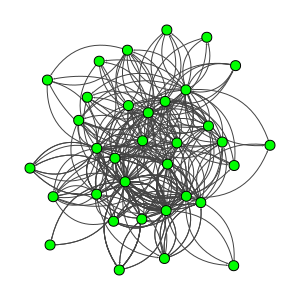

In [66]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(300, 300)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

Attacco Mirato

In [67]:
# Simula un attacco rimuovendo specifici attributi
results = simulate_edge_attack(g_airlines.copy(), 5, ordered_airlines)
metrics_edge_ordered = results["metrics"]
print("Attacco ordinato:", results)


Attacco ordinato: {'graph': <igraph.Graph object at 0x7920316ac340>, 'removed_edges': ['Ryanair', 'Alitalia', 'Meridiana', 'VOLOTEA Airways', 'Air One'], 'metrics': {'giant_component_size': [34, 28, 25, 25, 23, 20], 'edge_count': [425, 297, 197, 155, 115, 85], 'diameter': [4, 4, 4, 4, 5, 5], 'avg_path_length': [1.86096256684492, 1.9417989417989419, 2.0483333333333333, 2.125, 2.2015810276679844, 2.3026315789473686], 'efficiency': [0.6133392751039821, 0.40017825311942845, 0.30540701128936387, 0.2914438502673794, 0.2392899584076059, 0.1736036838978018], 'edges_removed': [0, 1, 2, 3, 4, 5]}}


<ipython-input-35-3806aaa81a8d>:7: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = graph.shortest_paths()


In [68]:
tratte_uniche = set()
for edge in results["graph"].es:
    source = results["graph"].vs[edge.source]['name']
    dest = results["graph"].vs[edge.target]['name']
    tratte_uniche.add((source, dest))

# Stampa tutte le tratte uniche
for tratta in tratte_uniche:
    print(f"Tratta aerea: {tratta[0]} -> {tratta[1]}")

Tratta aerea: Catania-Fontanarossa Airport -> Malpensa International Airport
Tratta aerea: Peretola Airport -> Falcone–Borsellino Airport
Tratta aerea: Reggio Calabria Airport -> Leonardo da Vinci–Fiumicino Airport
Tratta aerea: Cagliari Elmas Airport -> Peretola Airport
Tratta aerea: Malpensa International Airport -> Falcone–Borsellino Airport
Tratta aerea: Catania-Fontanarossa Airport -> Lampedusa Airport
Tratta aerea: Malpensa International Airport -> Leonardo da Vinci–Fiumicino Airport
Tratta aerea: Falcone–Borsellino Airport -> Peretola Airport
Tratta aerea: Catania-Fontanarossa Airport -> Naples International Airport
Tratta aerea: Malpensa International Airport -> Lamezia Terme Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Falcone–Borsellino Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Bolzano Airport
Tratta aerea: Leonardo da Vinci–Fiumicino Airport -> Reggio Calabria Airport
Tratta aerea: Lamezia Terme Airport -> Catania-Fontanarossa Airport
Tratt

In [69]:
len(tratte_uniche)

65

In [70]:
# Supponiamo di avere i due set già creati: tratte_uniche1 e tratte_uniche

# Differenza tra i due set
differenza_tratte = tratte_uniche1 - tratte_uniche

# Stampa gli elementi presenti in tratte_uniche1 ma non in tratte_uniche
for tratta in differenza_tratte:
    print(f"Tratta unica in tratte_uniche1: {tratta[0]} -> {tratta[1]}")


Tratta unica in tratte_uniche1: Il Caravaggio International Airport -> Bari Karol Wojtyła Airport
Tratta unica in tratte_uniche1: Pisa International Airport -> Cagliari Elmas Airport
Tratta unica in tratte_uniche1: Milano Linate Airport -> Brindisi – Salento Airport
Tratta unica in tratte_uniche1: Alghero-Fertilia Airport -> Bologna Guglielmo Marconi Airport
Tratta unica in tratte_uniche1: Turin Airport -> Brindisi – Salento Airport
Tratta unica in tratte_uniche1: Falcone–Borsellino Airport -> Genoa Cristoforo Colombo Airport
Tratta unica in tratte_uniche1: Vincenzo Florio Airport Trapani-Birgi -> Trieste–Friuli Venezia Giulia Airport
Tratta unica in tratte_uniche1: Leonardo da Vinci–Fiumicino Airport -> Lamezia Terme Airport
Tratta unica in tratte_uniche1: Bologna Guglielmo Marconi Airport -> Cagliari Elmas Airport
Tratta unica in tratte_uniche1: Vincenzo Florio Airport Trapani-Birgi -> Genoa Cristoforo Colombo Airport
Tratta unica in tratte_uniche1: Cagliari Elmas Airport -> Bologna 

In [71]:
numero_tratte_uniche= len(differenza_tratte)
numero_tratte_uniche

237

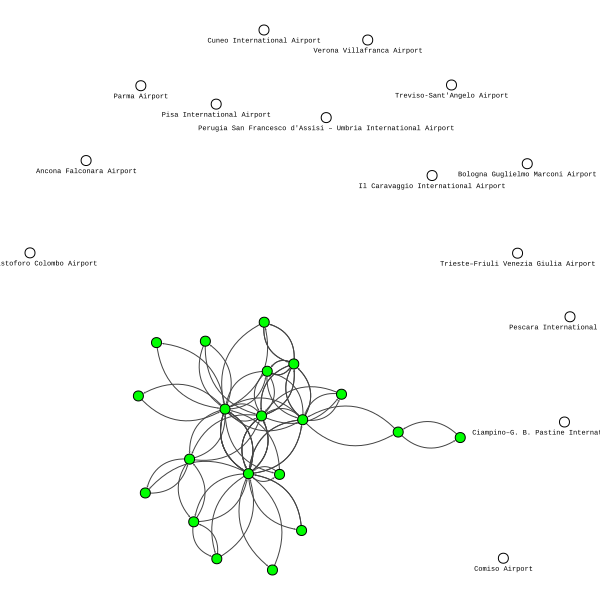

In [72]:
vertex_labels = [
    name if color != 'green' else ''
    for name, color in zip(results["graph"].vs['name'], results["graph"].vs['color'])
]

ig.plot(results["graph"]
        , vertex_label = vertex_labels
        , vertex_label_dist = 1.5
        , bbox=(600, 600)
        , margin=30
        , vertex_size= 10
        , edge_arrow_size=0.2
        , edge_curved=True
        , edge_label_dist= 2
        , vertex_label_size= 7
        , edge_label_size= 5
        ,vertex_color = results["graph"].vs["color"]
        )

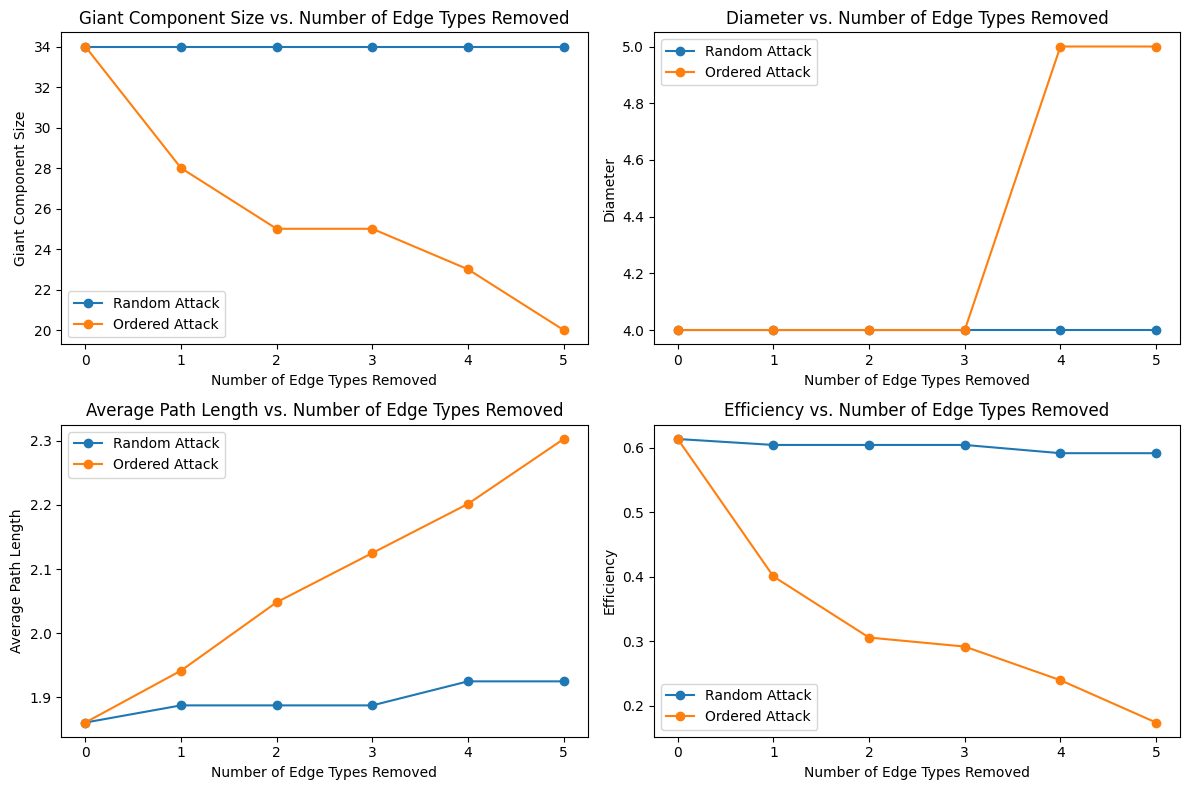

In [73]:
# Creazione dei grafici combinati
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['giant_component_size'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['giant_component_size'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Giant Component Size')
plt.title('Giant Component Size vs. Number of Edge Types Removed')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['diameter'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['diameter'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Diameter')
plt.title('Diameter vs. Number of Edge Types Removed')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['avg_path_length'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['avg_path_length'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Average Path Length')
plt.title('Average Path Length vs. Number of Edge Types Removed')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(metrics_edge_random['edges_removed'], metrics_edge_random['efficiency'], marker='o', label='Random Attack')
plt.plot(metrics_edge_ordered['edges_removed'], metrics_edge_ordered['efficiency'], marker='o', label='Ordered Attack')
plt.xlabel('Number of Edge Types Removed')
plt.ylabel('Efficiency')
plt.title('Efficiency vs. Number of Edge Types Removed')
plt.legend()

plt.tight_layout()
plt.show()